# MapReduce

## Learning Objectives

By the end of this notebook you will be able to:

1. **Explain** the MapReduce programming model and why it scales to petabyte datasets
2. **Define** the Map, Shuffle & Sort, and Reduce phases and their contracts
3. **Derive** the cost model in terms of communication cost and reducer size
4. **Implement** Map and Reduce functions for Word Count and matrix-vector multiplication
5. **Identify** which computational patterns fit the MapReduce model


## Problem Statement

Modern datasets — web crawls, social graphs, server logs — routinely reach terabytes or petabytes. A single machine cannot store or process them in reasonable time. We need a way to:

1. **Distribute** the data across hundreds or thousands of commodity machines
2. **Compute** over it in parallel with minimal programmer effort
3. **Tolerate failures** automatically — machines crash; the system must recover

### Why a New Model?

Ad-hoc parallelism requires the programmer to handle load balancing, fault recovery, data movement, and synchronisation. These concerns dwarf the actual computation logic.

### The MapReduce Insight

Express any computation as a pipeline of two pure functions:

| Function | Input | Output | Parallelism |
|----------|-------|--------|-------------|
| **Map** | (key₁, value₁) | list of (key₂, value₂) | One worker per input split — embarrassingly parallel |
| **Reduce** | (key₂, list[value₂]) | list of (key₃, value₃) | One worker per unique key — embarrassingly parallel |

The system handles everything in between: splitting input, routing intermediate pairs, sorting by key, restarting failed tasks, and writing output.

> **Central constraint:** the programmer never writes loops over the full dataset. All iteration is inside Map (over records in one split) or Reduce (over values for one key).


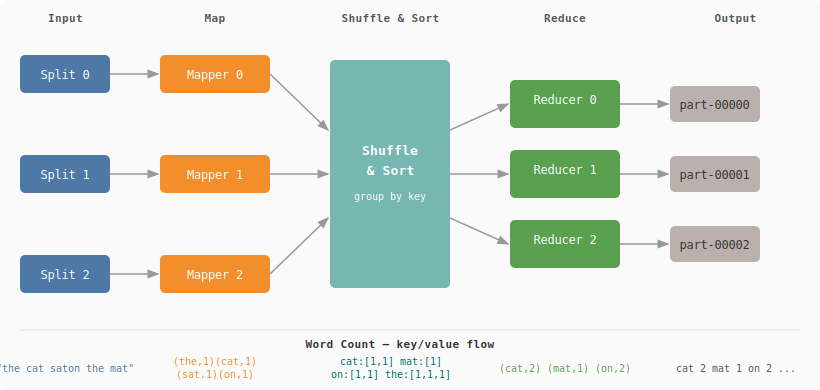

In [1]:
from IPython.display import SVG, display

svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="390" font-family="monospace" font-size="12">

  <!-- background -->
  <rect width="820" height="390" fill="#fafafa" rx="8"/>

  <!-- ── phase header labels ── -->
  <text x="65"  y="22" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">Input</text>
  <text x="215" y="22" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">Map</text>
  <text x="390" y="22" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">Shuffle &amp; Sort</text>
  <text x="565" y="22" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">Reduce</text>
  <text x="735" y="22" text-anchor="middle" fill="#555" font-size="11" font-weight="bold">Output</text>

  <!-- ── arrowhead marker ── -->
  <defs>
    <marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto">
      <polygon points="0 0, 8 3, 0 6" fill="#999"/>
    </marker>
  </defs>

  <!-- ═══ INPUT SPLITS (blue) ═══ -->
  <rect x="20"  y="55"  width="90" height="38" rx="5" fill="#4e79a7"/>
  <rect x="20"  y="155" width="90" height="38" rx="5" fill="#4e79a7"/>
  <rect x="20"  y="255" width="90" height="38" rx="5" fill="#4e79a7"/>
  <text x="65" y="79"  text-anchor="middle" fill="white">Split 0</text>
  <text x="65" y="179" text-anchor="middle" fill="white">Split 1</text>
  <text x="65" y="279" text-anchor="middle" fill="white">Split 2</text>

  <!-- splits → mappers -->
  <line x1="110" y1="74"  x2="158" y2="74"  stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="110" y1="174" x2="158" y2="174" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="110" y1="274" x2="158" y2="274" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- ═══ MAPPERS (orange) ═══ -->
  <rect x="160" y="55"  width="110" height="38" rx="5" fill="#f28e2b"/>
  <rect x="160" y="155" width="110" height="38" rx="5" fill="#f28e2b"/>
  <rect x="160" y="255" width="110" height="38" rx="5" fill="#f28e2b"/>
  <text x="215" y="79"  text-anchor="middle" fill="white">Mapper 0</text>
  <text x="215" y="179" text-anchor="middle" fill="white">Mapper 1</text>
  <text x="215" y="279" text-anchor="middle" fill="white">Mapper 2</text>

  <!-- mappers → shuffle -->
  <line x1="270" y1="74"  x2="328" y2="130" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="270" y1="174" x2="328" y2="174" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="270" y1="274" x2="328" y2="218" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- ═══ SHUFFLE & SORT (teal) ═══ -->
  <rect x="330" y="60" width="120" height="228" rx="5" fill="#76b7b2"/>
  <text x="390" y="155" text-anchor="middle" fill="white" font-size="13" font-weight="bold">Shuffle</text>
  <text x="390" y="175" text-anchor="middle" fill="white" font-size="13" font-weight="bold">&amp; Sort</text>
  <text x="390" y="200" text-anchor="middle" fill="white" font-size="10">group by key</text>

  <!-- shuffle → reducers -->
  <line x1="450" y1="130" x2="508" y2="104" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="450" y1="174" x2="508" y2="174" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="450" y1="218" x2="508" y2="244" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- ═══ REDUCERS (green) ═══ -->
  <rect x="510" y="80"  width="110" height="48" rx="5" fill="#59a14f"/>
  <rect x="510" y="150" width="110" height="48" rx="5" fill="#59a14f"/>
  <rect x="510" y="220" width="110" height="48" rx="5" fill="#59a14f"/>
  <text x="565" y="104" text-anchor="middle" fill="white">Reducer 0</text>
  <text x="565" y="174" text-anchor="middle" fill="white">Reducer 1</text>
  <text x="565" y="244" text-anchor="middle" fill="white">Reducer 2</text>

  <!-- reducers → output -->
  <line x1="620" y1="104" x2="668" y2="104" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="620" y1="174" x2="668" y2="174" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="620" y1="244" x2="668" y2="244" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- ═══ OUTPUT (grey) ═══ -->
  <rect x="670" y="86"  width="90" height="36" rx="5" fill="#bab0ac"/>
  <rect x="670" y="156" width="90" height="36" rx="5" fill="#bab0ac"/>
  <rect x="670" y="226" width="90" height="36" rx="5" fill="#bab0ac"/>
  <text x="715" y="109" text-anchor="middle" fill="#333">part-00000</text>
  <text x="715" y="179" text-anchor="middle" fill="#333">part-00001</text>
  <text x="715" y="249" text-anchor="middle" fill="#333">part-00002</text>

  <!-- ── Word Count example ── -->
  <line x1="20" y1="330" x2="800" y2="330" stroke="#ddd" stroke-width="1"/>
  <text x="400" y="348" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Word Count — key/value flow</text>

  <text x="65"  y="372" text-anchor="middle" fill="#4e79a7" font-size="10">"the cat sat\non the mat"</text>
  <text x="215" y="365" text-anchor="middle" fill="#f28e2b" font-size="10">(the,1)(cat,1)</text>
  <text x="215" y="378" text-anchor="middle" fill="#f28e2b" font-size="10">(sat,1)(on,1)</text>
  <text x="390" y="365" text-anchor="middle" fill="#006d6a" font-size="10">cat:[1,1] mat:[1]</text>
  <text x="390" y="378" text-anchor="middle" fill="#006d6a" font-size="10">on:[1,1] the:[1,1,1]</text>
  <text x="565" y="372" text-anchor="middle" fill="#59a14f" font-size="10">(cat,2) (mat,1) (on,2)</text>
  <text x="735" y="372" text-anchor="middle" fill="#555" font-size="10">cat 2  mat 1  on 2 ...</text>

</svg>
'''

display(SVG(svg))


## The MapReduce Model

### Formal Definitions

**Input split:** A contiguous chunk of the input dataset assigned to one Map task. Typically 64–256 MB (one HDFS block).

**Map function**

$$\text{map} : (k_1, v_1) \to \text{list}\bigl[(k_2, v_2)\bigr]$$

Applied independently to every record in a split. Produces zero or more *(key, value)* pairs called *intermediate pairs*.

**Shuffle & Sort phase** (performed by the framework, not the programmer)

$$\text{shuffle} : \text{list}\bigl[(k_2, v_2)\bigr] \to \bigl\{k_2 : \text{list}[v_2]\bigr\}$$

Groups all intermediate pairs by key and sorts within each group. This is the only data movement step — the communication bottleneck.

**Reduce function**

$$\text{reduce} : (k_2, \text{list}[v_2]) \to \text{list}\bigl[(k_3, v_3)\bigr]$$

Applied independently to each key and its associated value list. Produces the final output records.

---

### Key Properties

| Property | Explanation |
|----------|-------------|
| **Locality** | Map tasks run on the machine storing their split — network I/O avoided for input |
| **Fault tolerance** | Completed Map tasks are re-run if a reducer cannot reach their output; Reduce tasks are re-run from scratch on failure |
| **No shared state** | Map and Reduce tasks communicate only through the key-value interface — no locks, no shared memory |
| **Determinism** | Given the same input, Map and Reduce produce the same output — enables re-execution for recovery |


## Derivation of the Map Phase

### 1. Input Partitioning

The input dataset of size $S$ bytes is split into $M$ chunks of roughly equal size:

$$\text{split}_i \approx \frac{S}{M} \text{ bytes}, \quad i = 0, 1, \ldots, M-1$$

Each split is processed by exactly one Map task. The number $M$ is chosen so that each split fits comfortably in memory.

### 2. Map Execution

For each record $(k_1^{(r)}, v_1^{(r)})$ in split $i$, the framework calls:

$$\text{map}\bigl(k_1^{(r)},\, v_1^{(r)}\bigr) \to \bigl[(k_2^{(1)}, v_2^{(1)}),\, (k_2^{(2)}, v_2^{(2)}),\, \ldots\bigr]$$

All intermediate pairs are written to local disk (not the distributed filesystem).

### 3. Combiner (Optional)

A *combiner* applies a Reduce-like aggregation locally on the Map output before network transfer. For associative/commutative operations (e.g. sum, max) it reduces communication cost with no change to correctness:

$$\text{combiner}(k_2, \text{local list}[v_2]) \to (k_2, \text{partial aggregate})$$

### 4. Partitioning

Each intermediate key is hashed to one of $R$ reducers:

$$\text{partition}(k_2) = h(k_2) \bmod R$$

This guarantees that all values for the same key arrive at the same reducer.


## Derivation of the Shuffle & Sort Phase

The framework, not the programmer, performs three sub-steps:

**Step 1 — Fetch:** Each Reducer pulls the intermediate pairs assigned to it from every Mapper's local disk. This is the sole network transfer in the entire pipeline.

**Step 2 — Merge-Sort:** Each Reducer sorts its received pairs by key using an external merge sort (the data may not fit in memory):

$$\bigl[(k_2, v), \ldots\bigr] \xrightarrow{\text{sort}} \bigl[(k_2^{(a)}, v_1), (k_2^{(a)}, v_2), \ldots, (k_2^{(b)}, v_1), \ldots\bigr]$$

**Step 3 — Group:** Consecutive records with the same key are grouped and presented to the Reduce function as a single `(key, iterator_of_values)` call.

### Communication Cost

The total bytes transferred during shuffle is the **communication cost** — the dominant performance metric for MapReduce jobs:

$$Q = \sum_{i=0}^{M-1} \sum_{j=0}^{R-1} |\text{intermediate pairs sent from mapper } i \text{ to reducer } j|$$

Minimising $Q$ is the primary optimisation goal when designing MapReduce algorithms.


## Derivation of the Reduce Phase

For each unique key $k_2$ in sorted order, the framework calls:

$$\text{reduce}\bigl(k_2,\; [v_2^{(1)},\, v_2^{(2)},\, \ldots,\, v_2^{(n_k)}]\bigr) \to [(k_3^{(1)}, v_3^{(1)}),\, \ldots]$$

**Reduce task contract:**
- Receives values in *some* consistent order (framework-defined, typically sorted)
- Must produce a finite output for each key
- Writes output directly to the distributed filesystem (HDFS/GCS/S3)

**Reducer size** — the maximum amount of data processed by any single Reducer:

$$q = \max_{j} \sum_{i} |\text{pairs sent from mapper } i \text{ to reducer } j|$$

A large $q$ causes stragglers. Choosing $R$ and the partition function to balance $q$ across reducers is critical.


## Cost Model

The two quantities that govern MapReduce performance:

| Quantity | Definition | Goal |
|----------|-----------|------|
| **Communication cost** $Q$ | Total bytes in all intermediate (key, value) pairs | Minimise |
| **Reducer size** $q$ | Max bytes seen by any one Reducer | Minimise (balance load) |

**Replication rate** $r$: average number of intermediate pairs produced per input record. Relates to communication cost:

$$Q \approx r \times S$$

### Algorithmic Trade-off

For many problems (e.g. computing all pairs of similar items), the number of intermediate pairs grows quadratically with input size. The art of MapReduce algorithm design is choosing the right partitioning so that:

1. Each Reducer receives enough data to make progress
2. No single Reducer is overwhelmed (balanced $q$)
3. Total communication $Q$ is small

### When MapReduce is the Right Tool

| Fits well | Does not fit well |
|-----------|------------------|
| Batch processing of independent records | Iterative algorithms (many passes) |
| Aggregation / group-by queries | Low-latency queries |
| Join of two large relations | Fine-grained inter-task communication |
| Embarrassingly parallel computations | Algorithms with irregular data dependencies |


## Algorithm Steps

### Map Phase

1. **Split** input into $M$ chunks; assign one chunk per Map worker
2. **For each record** in the chunk, call `map(key1, value1) -> [(key2, value2), ...]`
3. **Buffer** intermediate pairs in memory; spill to local disk when full
4. **Apply combiner** (if defined) to reduce local output size
5. **Partition** pairs by `hash(key2) % R` so each Reducer gets its share

### Shuffle & Sort Phase (framework)

6. **Fetch** — each Reducer pulls its partition from all Mapper local disks
7. **Merge-sort** fetched pairs by key
8. **Group** consecutive same-key pairs into a single iterator

### Reduce Phase

9. **For each unique key** and its value list, call `reduce(key2, [v2, ...]) -> [(key3, v3), ...]`
10. **Write** output records to the distributed filesystem


In [2]:
from collections import defaultdict


def map_word_count(filename, content):
    """Map: (filename, text) -> list of (word, 1)."""
    pairs = []
    for word in content.lower().split():
        word = word.strip(".,!?;:\"'")
        if word:
            pairs.append((word, 1))
    return pairs


def shuffle_and_sort(mapped_pairs):
    """Shuffle: group values by key."""
    grouped = defaultdict(list)
    for key, value in mapped_pairs:
        grouped[key].append(value)
    # Sort phase: return keys in sorted order (deterministic output)
    return dict(sorted(grouped.items()))


def reduce_word_count(key, values):
    """Reduce: (word, [1,1,1,...]) -> (word, total_count)."""
    return (key, sum(values))


def mapreduce(documents, map_fn, reduce_fn):
    """
    Inputs
    ------
    documents : list of (name, content) tuples — one per input split
    map_fn    : callable (name, content) -> list of (key, value)
    reduce_fn : callable (key, list_of_values) -> (key, result)

    Output
    ------
    results : list of (key, result) tuples in key-sorted order
    """
    # Map phase — run map_fn on each split independently (parallelisable)
    all_pairs = []
    for name, content in documents:
        all_pairs.extend(map_fn(name, content))

    # Shuffle & Sort phase — group all values by key
    grouped = shuffle_and_sort(all_pairs)

    # Reduce phase — run reduce_fn on each key's value list (parallelisable)
    results = []
    for key, values in grouped.items():
        results.append(reduce_fn(key, values))

    return results


# ── Demo ──────────────────────────────────────────────────────────────────────
documents = [
    ("doc0", "the cat sat on the mat"),
    ("doc1", "the cat in the hat"),
    ("doc2", "one fish two fish red fish blue fish"),
]

results = mapreduce(documents, map_word_count, reduce_word_count)
for word, count in results:
    print(f"{word:12s} {count}")


blue         1
cat          2
fish         4
hat          1
in           1
mat          1
on           1
one          1
red          1
sat          1
the          4
two          1


In [3]:
import numpy as np


def map_matvec(row_index, row_data, x_vector):
    """
    Map function for matrix-vector product y = M @ x.
    For each non-zero entry M[i,j] = v, emit (i, v * x[j]).
    row_data : list of (col_index, value) — sparse row representation
    """
    pairs = []
    for j, v in row_data:
        pairs.append((row_index, v * x_vector[j]))
    return pairs


def reduce_matvec(row_index, partial_products):
    """Reduce: sum all partial products for row i -> y[i]."""
    return (row_index, sum(partial_products))


def mapreduce_matvec(M_sparse, x):
    """
    Sparse matrix-vector multiplication via MapReduce.
    M_sparse : list of (row_i, [(col_j, val), ...])
    x        : 1-D numpy array
    """
    all_pairs = []
    for row_i, row_data in M_sparse:
        all_pairs.extend(map_matvec(row_i, row_data, x))

    grouped = defaultdict(list)
    for k, v in all_pairs:
        grouped[k].append(v)

    results = {}
    for k, vals in grouped.items():
        _, y_i = reduce_matvec(k, vals)
        results[k] = y_i

    n_rows = max(results) + 1
    return np.array([results[i] for i in range(n_rows)])


# ── Verify against numpy ───────────────────────────────────────────────────────
M = np.array([[1, 0, 2],
              [0, 3, 0],
              [4, 0, 5]], dtype=float)
x = np.array([1.0, 2.0, 3.0])

M_sparse = [(i, [(j, M[i,j]) for j in range(M.shape[1]) if M[i,j] != 0])
            for i in range(M.shape[0])]

y_mr = mapreduce_matvec(M_sparse, x)
y_np = M @ x

print("MapReduce result:", y_mr)
print("NumPy result:    ", y_np)
print("Match:", np.allclose(y_mr, y_np))


MapReduce result: [ 7.  6. 19.]
NumPy result:     [ 7.  6. 19.]
Match: True
